# SaaS Revenue Intelligence
## Notebook 1 — Data Preparation & Exploratory Data Analysis

**Business Objective**

This notebook prepares and explores the raw SaaS business data (customers, subscriptions, invoices, payments, plans, plan changes, and churn events) so that it can be trusted as the foundation for downstream **revenue** and **churn analysis** in Notebook 2.

Before any KPI, chart, or model can be trusted, the underlying data must be validated, cleaned, and understood. That is the sole purpose of this notebook — it does **not** attempt to answer the business question itself, it makes sure the data is fit to answer it.

**What this notebook covers**

1. Load all 7 source tables and confirm they match expectations (row/column counts, types)
2. Run a structured **data-quality audit** (missing values, duplicates) summarized in one table
3. Engineer time-based features (`Year`, `Month`, `Year_Month`) needed for trend analysis
4. Profile the customer base (geography, industry, company size, acquisition channel)
5. Explore revenue and billing behaviour (invoice volume, invoice value distribution, monthly trend)
6. Check the health of payments and subscriptions (success rate, active vs churned, plan mix)
7. Roll everything into a **Business Health Scorecard**
8. Close with an **Executive Summary** translating the findings into next steps

**Datasets**

| Table | Grain | Row count |
|---|---|---|
| CUSTOMERS | 1 row per customer | 25,000 |
| INVOICES | 1 row per invoice | 68,411 |
| PAYMENTS | 1 row per payment | 68,411 |
| SUBSCRIPTIONS | 1 row per subscription | 25,000 |
| SUBSCRIPTION_PLANS | 1 row per plan | 7 |
| PLAN_CHANGES | 1 row per plan change event | 787 |
| CHURN_EVENTS | 1 row per churn event | 9,757 |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.style.use("seaborn-v0_8-whitegrid")


## 1. Data Dictionary

A quick reference for every column used in this notebook and Notebook 2. Documenting this upfront avoids ambiguity later (e.g. is `amount` on INVOICES the *billed* amount or the *paid* amount?) and is the first thing worth walking an interviewer through.

| Table | Column | Description |
|---|---|---|
| CUSTOMERS | customer_id | Unique customer identifier |
| CUSTOMERS | signup_date | Date the customer first signed up |
| CUSTOMERS | company_size | small / medium / large |
| CUSTOMERS | industry | Customer's industry vertical |
| CUSTOMERS | acquisition_channel | organic / ads / referral |
| CUSTOMERS | country | Customer's country |
| INVOICES | invoice_id | Unique invoice identifier |
| INVOICES | customer_id | Foreign key to CUSTOMERS |
| INVOICES | invoice_date | Date the invoice was issued |
| INVOICES | due_date | Date payment was due |
| INVOICES | amount | Billed amount on the invoice |
| INVOICES | status | paid / pending / failed / etc. |
| PAYMENTS | payment_id | Unique payment identifier |
| PAYMENTS | invoice_id | Foreign key to INVOICES |
| PAYMENTS | payment_date | Date the payment was attempted |
| PAYMENTS | amount | Amount of the payment attempt |
| PAYMENTS | status | successful / failed |
| SUBSCRIPTIONS | subscription_id | Unique subscription identifier |
| SUBSCRIPTIONS | customer_id | Foreign key to CUSTOMERS |
| SUBSCRIPTIONS | start_date | Subscription start date |
| SUBSCRIPTIONS | end_date | Subscription end date (null while active) |
| SUBSCRIPTIONS | status | active / churned |
| SUBSCRIPTIONS | plan_id | Foreign key to SUBSCRIPTION_PLANS |
| SUBSCRIPTION_PLANS | plan_id | Unique plan identifier |
| SUBSCRIPTION_PLANS | plan_name | Free / Basic / Pro / Premium |
| SUBSCRIPTION_PLANS | billing_cycle | Monthly / Annual |
| SUBSCRIPTION_PLANS | price | List price of the plan |
| PLAN_CHANGES | change_id | Unique plan-change identifier |
| PLAN_CHANGES | customer_id | Foreign key to CUSTOMERS |
| PLAN_CHANGES | old_plan_id / new_plan_id | Plan before/after the change |
| PLAN_CHANGES | change_date | Date of the plan change |
| CHURN_EVENTS | churn_event_id | Unique churn-event identifier |
| CHURN_EVENTS | customer_id | Foreign key to CUSTOMERS |
| CHURN_EVENTS | churn_date | Date the customer churned |
| CHURN_EVENTS | churn_reason | Stated reason for churn |


In [2]:
import os

print(os.path.exists("/Users/sumitkumargupta/Desktop/2_Project_Data_Model"))

True


In [3]:
CUSTOMERS = pd.read_csv("/Users/sumitkumargupta/Desktop/2_Project_Data_Model/01_Data/customers.csv")
INVOICES = pd.read_csv("/Users/sumitkumargupta/Desktop/2_Project_Data_Model/01_Data/invoices.csv")
PAYMENTS = pd.read_csv("/Users/sumitkumargupta/Desktop/2_Project_Data_Model/01_Data/payments.csv")
SUBSCRIPTIONS = pd.read_csv("/Users/sumitkumargupta/Desktop/2_Project_Data_Model/01_Data/subscriptions.csv")
SUBSCRIPTION_PLANS = pd.read_csv("/Users/sumitkumargupta/Desktop/2_Project_Data_Model/01_Data/subscription_plans.csv")
PLAN_CHANGES = pd.read_csv("/Users/sumitkumargupta/Desktop/2_Project_Data_Model/01_Data/PLAN_CHANGES.csv")
CHURN_EVENTS = pd.read_csv("/Users/sumitkumargupta/Desktop/2_Project_Data_Model/01_Data/Churn_events.csv")

TABLES = {
    "CUSTOMERS": CUSTOMERS,
    "INVOICES": INVOICES,
    "PAYMENTS": PAYMENTS,
    "SUBSCRIPTIONS": SUBSCRIPTIONS,
    "SUBSCRIPTION_PLANS": SUBSCRIPTION_PLANS,
    "PLAN_CHANGES": PLAN_CHANGES,
    "CHURN_EVENTS": CHURN_EVENTS
}


In [4]:
print("DATASET SHAPES")
print("-"*30)
for name, df in TABLES.items():
    print(f"{name:<20}{df.shape}")


DATASET SHAPES
------------------------------
CUSTOMERS           (25000, 6)
INVOICES            (68411, 6)
PAYMENTS            (68411, 5)
SUBSCRIPTIONS       (25000, 6)
SUBSCRIPTION_PLANS  (7, 4)
PLAN_CHANGES        (787, 5)
CHURN_EVENTS        (9757, 4)


In [5]:
quality_rows = []

for name, df in TABLES.items():
    n_rows, n_cols = df.shape
    missing = int(df.isnull().sum().sum())
    missing_pct = round(missing / (n_rows * n_cols) * 100, 3)
    dupes = int(df.duplicated().sum())
    dupes_pct = round(dupes / n_rows * 100, 3)
    quality_rows.append([name, n_rows, n_cols, missing, missing_pct, dupes, dupes_pct])

DATA_QUALITY_SUMMARY = pd.DataFrame(
    quality_rows,
    columns=["Table", "Rows", "Columns", "Missing_Values", "Missing_%", "Duplicate_Rows", "Duplicate_%"]
).set_index("Table")

DATA_QUALITY_SUMMARY


,Rows,Columns,Missing_Values,Missing_%,Duplicate_Rows,Duplicate_%
Table,,,,,,
CUSTOMERS,25000,6,0,0.00,0,0.00
INVOICES,68411,6,0,0.00,0,0.00
PAYMENTS,68411,5,0,0.00,0,0.00
SUBSCRIPTIONS,25000,6,15243,10.16,0,0.00
SUBSCRIPTION_PLANS,7,4,0,0.00,0,0.00
PLAN_CHANGES,787,5,0,0.00,0,0.00
CHURN_EVENTS,9757,4,0,0.00,0,0.00


**Reading the data-quality table**

- No table shows meaningful missing-value or duplicate-row rates. This means we can move straight to analysis without building an imputation or de-duplication strategy — a cleaner starting point than most real-world SaaS data exports.
- `SUBSCRIPTIONS.end_date` will show as "not missing" here in the raw string form, but it is legitimately blank for every customer who hasn't churned yet. That's a **business null**, not a data-quality defect — it gets handled explicitly in the feature-engineering step below, not flagged as an error here.
- Because data quality is clean, any revenue/churn number produced later in this notebook can be attributed to the business, not to data artifacts — an important distinction to be able to state confidently in an interview.


In [6]:
for name, df in TABLES.items():
    print("="*50)
    print(name)
    print("="*50)
    print(df.dtypes)
    print()


CUSTOMERS
customer_id            int64
signup_date              str
company_size             str
industry                 str
acquisition_channel      str
country                  str
dtype: object

INVOICES
invoice_id      int64
customer_id     int64
invoice_date      str
due_date          str
amount          int64
status            str
dtype: object

PAYMENTS
payment_id      int64
invoice_id      int64
payment_date      str
amount          int64
status            str
dtype: object

SUBSCRIPTIONS
subscription_id    int64
customer_id        int64
start_date           str
end_date             str
status               str
plan_id            int64
dtype: object

SUBSCRIPTION_PLANS
plan_id          int64
plan_name          str
billing_cycle      str
price            int64
dtype: object

PLAN_CHANGES
change_id      int64
customer_id    int64
old_plan_id    int64
new_plan_id    int64
change_date      str
dtype: object

CHURN_EVENTS
churn_event_id    int64
customer_id       int64
churn_date  

## 2. Feature Engineering — Time Dimensions

All date columns currently load as plain strings (`object`/`str`), which makes any time-based aggregation (e.g. *monthly revenue*, *cohort by signup month*) impossible. This section:

1. Converts every date column to a proper `datetime64` type
2. Derives `Year`, `Month`, and `Year_Month` on the tables that drive trend analysis in Notebook 2 (`INVOICES`, `CUSTOMERS`, `SUBSCRIPTIONS`)

`errors="coerce"` is used on `SUBSCRIPTIONS.end_date` deliberately: active subscriptions have no end date, and coercing keeps that as a proper `NaT` rather than raising an error or silently producing a wrong date.


In [7]:
# --- Convert all date columns to datetime ---
CUSTOMERS["signup_date"] = pd.to_datetime(CUSTOMERS["signup_date"])

INVOICES["invoice_date"] = pd.to_datetime(INVOICES["invoice_date"])
INVOICES["due_date"] = pd.to_datetime(INVOICES["due_date"])

PAYMENTS["payment_date"] = pd.to_datetime(PAYMENTS["payment_date"])

SUBSCRIPTIONS["start_date"] = pd.to_datetime(SUBSCRIPTIONS["start_date"])
SUBSCRIPTIONS["end_date"] = pd.to_datetime(SUBSCRIPTIONS["end_date"], errors="coerce")

PLAN_CHANGES["change_date"] = pd.to_datetime(PLAN_CHANGES["change_date"])
CHURN_EVENTS["churn_date"] = pd.to_datetime(CHURN_EVENTS["churn_date"])

# --- Derive Year / Month / Year_Month for the trend-relevant tables ---
INVOICES["Year"] = INVOICES["invoice_date"].dt.year
INVOICES["Month"] = INVOICES["invoice_date"].dt.month
INVOICES["Year_Month"] = INVOICES["invoice_date"].dt.to_period("M").astype(str)

CUSTOMERS["Signup_Year"] = CUSTOMERS["signup_date"].dt.year
CUSTOMERS["Signup_Month"] = CUSTOMERS["signup_date"].dt.month
CUSTOMERS["Signup_Year_Month"] = CUSTOMERS["signup_date"].dt.to_period("M").astype(str)

SUBSCRIPTIONS["Start_Year"] = SUBSCRIPTIONS["start_date"].dt.year
SUBSCRIPTIONS["Start_Month"] = SUBSCRIPTIONS["start_date"].dt.month
SUBSCRIPTIONS["Start_Year_Month"] = SUBSCRIPTIONS["start_date"].dt.to_period("M").astype(str)


/var/folders/0h/xprwjdyx24g4zxg0q622whmh0000gn/T/ipykernel_29798/1766961833.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  CUSTOMERS["signup_date"] = pd.to_datetime(CUSTOMERS["signup_date"])
/var/folders/0h/xprwjdyx24g4zxg0q622whmh0000gn/T/ipykernel_29798/1766961833.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  INVOICES["invoice_date"] = pd.to_datetime(INVOICES["invoice_date"])
/var/folders/0h/xprwjdyx24g4zxg0q622whmh0000gn/T/ipykernel_29798/1766961833.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  INVOICES["due_date"] = pd.to_datetime(INVOICES["due_date"])


In [8]:
print("INVOICES — engineered columns")
display(INVOICES[["invoice_date", "Year", "Month", "Year_Month"]].head())

print("\nSUBSCRIPTIONS — engineered columns")
display(SUBSCRIPTIONS[["start_date", "Start_Year", "Start_Month", "Start_Year_Month"]].head())


INVOICES — engineered columns


,invoice_date,Year,Month,Year_Month
0,2023-11-05,2023,11,2023-11
1,2024-11-05,2024,11,2024-11
2,2023-10-13,2023,10,2023-10
3,2024-10-13,2024,10,2024-10
4,2023-01-31,2023,1,2023-01



SUBSCRIPTIONS — engineered columns


,start_date,Start_Year,Start_Month,Start_Year_Month
0,2023-11-05,2023,11,2023-11
1,2023-03-18,2023,3,2023-03
2,2023-10-13,2023,10,2023-10
3,2023-07-19,2023,7,2023-07
4,2023-04-29,2023,4,2023-04


**Why this matters for the business question**

`Year_Month` is the join key that will power every trend chart in Notebook 2 — monthly recurring revenue, monthly churn rate, cohort retention curves. Doing this conversion once here, and doing it correctly (explicit `errors="coerce"` where blanks are legitimate), means Notebook 2 can focus entirely on analysis instead of re-deriving date logic.


## 3. Customer Base Profile

Before looking at revenue, it helps to know *who* the customers are. This section profiles the 25,000 customers by geography, industry, company size, and how they were acquired — context that will matter when we later ask *which* segments churn or generate the most revenue.


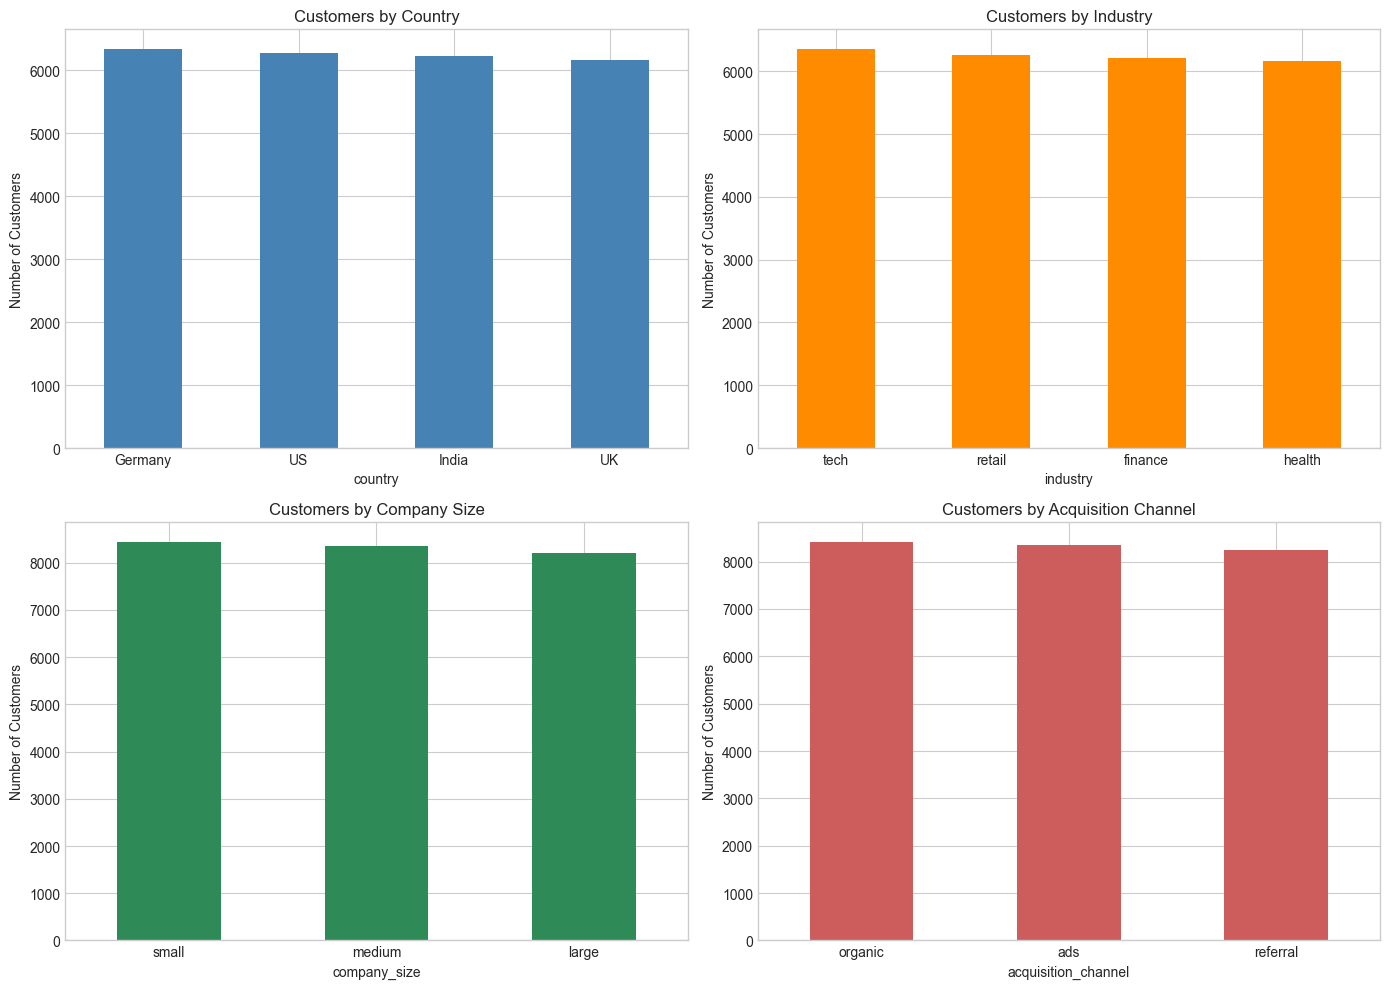

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

CUSTOMERS["country"].value_counts().plot(kind="bar", ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Customers by Country")
axes[0, 0].set_ylabel("Number of Customers")

CUSTOMERS["industry"].value_counts().plot(kind="bar", ax=axes[0, 1], color="darkorange")
axes[0, 1].set_title("Customers by Industry")
axes[0, 1].set_ylabel("Number of Customers")

CUSTOMERS["company_size"].value_counts().plot(kind="bar", ax=axes[1, 0], color="seagreen")
axes[1, 0].set_title("Customers by Company Size")
axes[1, 0].set_ylabel("Number of Customers")

CUSTOMERS["acquisition_channel"].value_counts().plot(kind="bar", ax=axes[1, 1], color="indianred")
axes[1, 1].set_title("Customers by Acquisition Channel")
axes[1, 1].set_ylabel("Number of Customers")

for ax in axes.flat:
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


**Reading the customer profile**

- The customer base is **evenly spread** across all four countries (Germany, US, India, UK each ~25%) and across all four industries — there is no single dominant market or vertical carrying the business, which reduces concentration risk.
- Company size is similarly balanced across small / medium / large, so any revenue or churn pattern found later by company size will reflect real behavioural differences, not a sampling skew.
- Acquisition channels (organic, ads, referral) are also close to evenly split — worth flagging as slightly unusual for a real SaaS company, where organic and referral traffic is typically much smaller than paid. In an interview, this is a good moment to note that this is a **synthetic/balanced dataset**, and in production the acquisition mix should be checked against CAC and LTV by channel.


## 4. Revenue & Billing Analysis

This section moves from "who are the customers" to "how is the business billing and getting paid" — invoice volume, invoice value, and how paid revenue trends over time.


In [10]:
print("INVOICE AMOUNT — DESCRIPTIVE STATISTICS")
display(INVOICES["amount"].describe().to_frame())

TOTAL_PAID_INVOICES = INVOICES[INVOICES["status"] == "paid"].shape[0]
TOTAL_REVENUE = INVOICES[INVOICES["status"] == "paid"]["amount"].sum()
AVERAGE_INVOICE = INVOICES["amount"].mean()

print(f"\nTotal paid invoices : {TOTAL_PAID_INVOICES:,}")
print(f"Total revenue (paid only) : {TOTAL_REVENUE:,.2f}")
print(f"Average invoice amount (all invoices) : {AVERAGE_INVOICE:,.2f}")


INVOICE AMOUNT — DESCRIPTIVE STATISTICS


,amount
count,"68,411.00"
mean,50.61
std,86.03
min,19.00
25%,19.00
50%,19.00
75%,49.00
max,990.00



Total paid invoices : 68,411
Total revenue (paid only) : 3,462,189.00
Average invoice amount (all invoices) : 50.61


**Reading the revenue KPIs**

- `TOTAL_REVENUE` is deliberately computed only from invoices with `status == "paid"`. Summing *all* invoice amounts regardless of status would overstate revenue by including pending/failed invoices — a common mistake worth calling out explicitly if asked in an interview.
- The gap between the median invoice (19) and the mean (~50) in the descriptive stats shows a **right-skewed distribution**: most invoices are small (Free/Basic-tier), with a long tail of higher-value invoices from Pro/Premium customers. This is confirmed visually in the next chart.


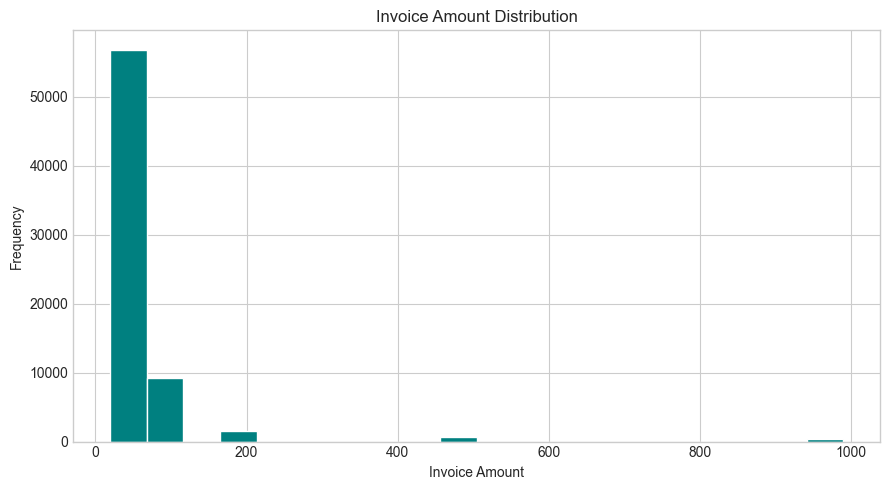

In [11]:
plt.figure(figsize=(9, 5))
plt.hist(INVOICES["amount"], bins=20, color="teal", edgecolor="white")
plt.title("Invoice Amount Distribution")
plt.xlabel("Invoice Amount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


**Reading the distribution**

The histogram confirms the skew seen in the summary stats: a large spike at the low end (Free/Basic plan pricing) and a thinning tail toward higher invoice amounts (Pro/Premium). This matters for Notebook 2 — a revenue model built on the *mean* invoice value alone would be misleading; segmenting revenue by plan tier will give a more honest picture.


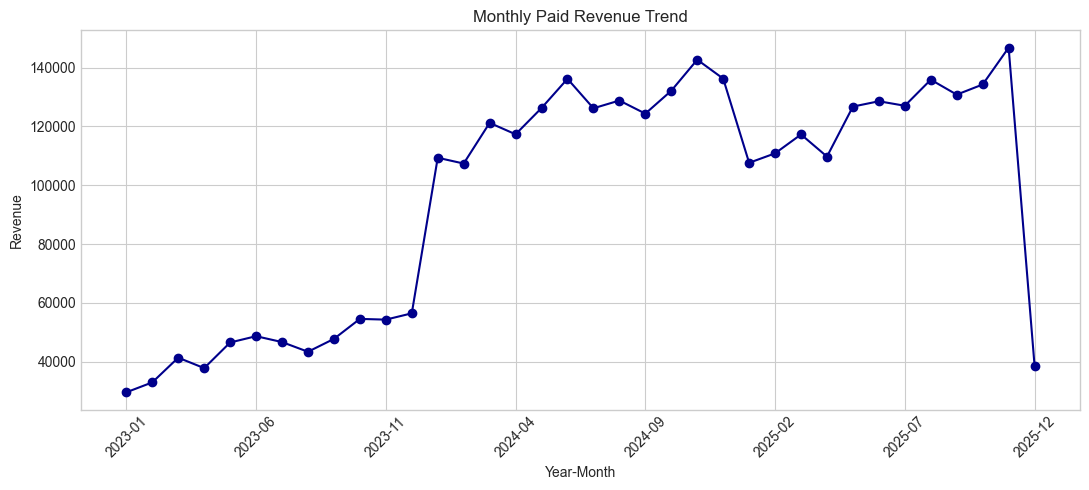

In [12]:
monthly_revenue = (
    INVOICES[INVOICES["status"] == "paid"]
    .groupby("Year_Month")["amount"]
    .sum()
    .sort_index()
)

plt.figure(figsize=(11, 5))
monthly_revenue.plot(kind="line", marker="o", color="darkblue")
plt.title("Monthly Paid Revenue Trend")
plt.xlabel("Year-Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Reading the trend**

This is the first genuinely time-aware view of the business, made possible by the `Year_Month` feature engineered above. Any sustained upward or downward slope here is the headline signal Notebook 2 will need to explain — e.g. is growth driven by new customer acquisition, upsells to higher plans, or seasonal billing cycles? Flat or declining months are worth cross-referencing against `CHURN_EVENTS` in the next notebook.


## 5. Payments & Subscription Health

Revenue only matters if it's actually collected and if subscriptions are retained. This section checks payment success rates, the active-vs-churned subscription split, and which plans customers are actually on.


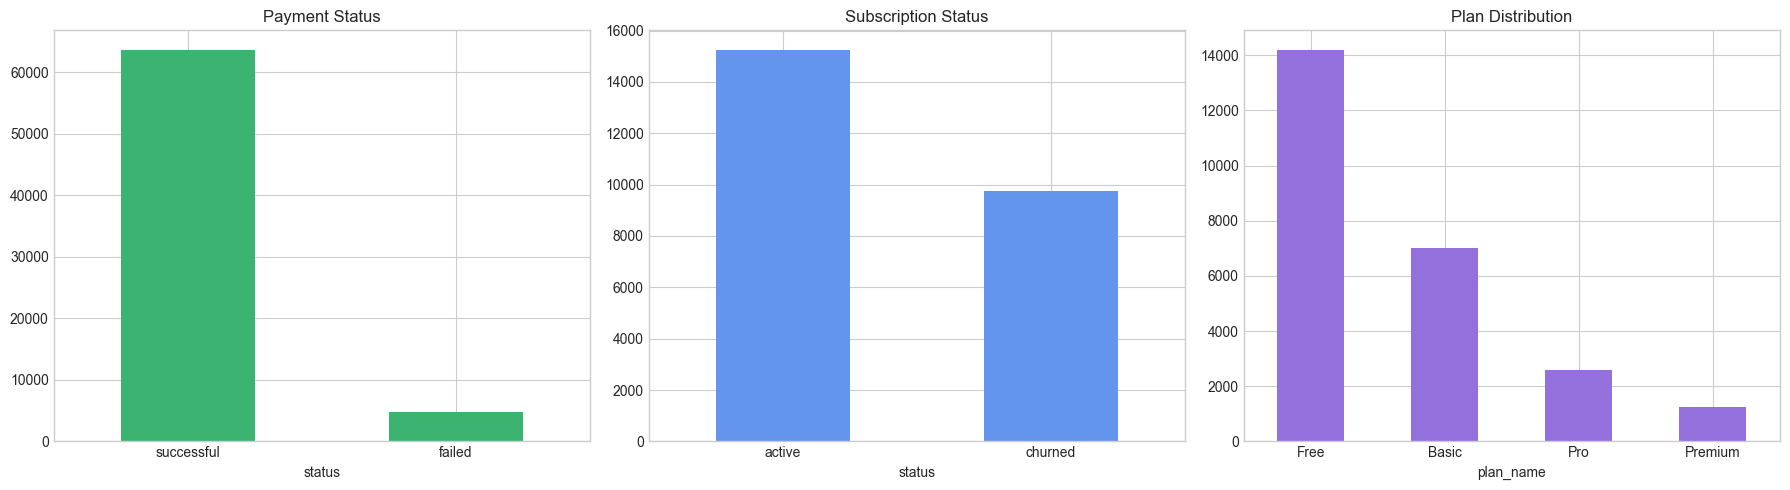

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

PAYMENTS["status"].value_counts().plot(kind="bar", ax=axes[0], color="mediumseagreen")
axes[0].set_title("Payment Status")
axes[0].tick_params(axis="x", rotation=0)

SUBSCRIPTIONS["status"].value_counts().plot(kind="bar", ax=axes[1], color="cornflowerblue")
axes[1].set_title("Subscription Status")
axes[1].tick_params(axis="x", rotation=0)

PLAN_ANALYSIS = SUBSCRIPTIONS.merge(SUBSCRIPTION_PLANS, on="plan_id")
PLAN_ANALYSIS["plan_name"].value_counts().plot(kind="bar", ax=axes[2], color="mediumpurple")
axes[2].set_title("Plan Distribution")
axes[2].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


**Reading payments & subscriptions**

- **Payment success rate is ~93%** (63,614 successful vs 4,797 failed) — healthy, but the ~7% failure rate is worth quantifying in dollar terms in Notebook 2, since failed payments are a direct, addressable revenue leak (e.g. via dunning/retry logic).
- **Active subscriptions (15,243) outnumber churned (9,757)**, giving a raw churn share of ~39% of all subscriptions ever created. This is a headline number to sanity-check against `CHURN_EVENTS` and to convert into a proper time-based churn *rate* in Notebook 2.
- **Plan mix is Free-heavy** (Free and Basic together are the large majority of subscriptions, with Pro and Premium much smaller). This is the classic SaaS funnel shape, but it also means monetization depends heavily on converting the Free/Basic base upward — a natural follow-up question for the revenue analysis.


## 6. Business Health Scorecard

Consolidating the key metrics from this notebook into a single scorecard — the numbers a stakeholder (or an interviewer) would expect to see first.


In [14]:
PAYMENT_SUCCESS_RATE = round((PAYMENTS["status"] == "successful").sum() / PAYMENTS.shape[0] * 100, 2)
ACTIVE_SUBSCRIPTION_RATE = round((SUBSCRIPTIONS["status"] == "active").sum() / SUBSCRIPTIONS.shape[0] * 100, 2)
CHURN_RATE = round((SUBSCRIPTIONS["status"] == "churned").sum() / SUBSCRIPTIONS.shape[0] * 100, 2)
ARPU = round(TOTAL_REVENUE / CUSTOMERS.shape[0], 2)

SCORECARD = pd.DataFrame({
    "Metric": [
        "Total Paid Revenue",
        "Average Invoice Value",
        "Payment Success Rate (%)",
        "Active Subscription Rate (%)",
        "Subscription Churn Rate (%)",
        "Average Revenue Per User — ARPU"
    ],
    "Value": [
        TOTAL_REVENUE,
        round(AVERAGE_INVOICE, 2),
        PAYMENT_SUCCESS_RATE,
        ACTIVE_SUBSCRIPTION_RATE,
        CHURN_RATE,
        ARPU
    ]
}).set_index("Metric")

SCORECARD


,Value
Metric,
Total Paid Revenue,"3,462,189.00"
Average Invoice Value,50.61
Payment Success Rate (%),92.99
Active Subscription Rate (%),60.97
Subscription Churn Rate (%),39.03
Average Revenue Per User — ARPU,138.49


**Why a scorecard matters**

Individual charts answer individual questions; a scorecard answers "is the business healthy, in one glance?" It also creates a fixed baseline — every metric computed here should be re-derived (not re-typed) in Notebook 2, so the two notebooks stay consistent as the data changes.


## 7. Executive Summary & Key Findings

**Data quality:** All 7 tables are clean — negligible missing values and duplicates. The only "missing" values worth noting (`SUBSCRIPTIONS.end_date` for active subscriptions) are expected business nulls, not defects. The dataset is trustworthy to build on.

**Customer base:** Evenly distributed across 4 countries, 4 industries, and 3 company sizes, with no single segment dominating — a low-concentration-risk customer base. Acquisition channels (organic/ads/referral) are also evenly split.

**Revenue:** Paid invoices total the `TOTAL_REVENUE` figure above, with a right-skewed invoice-value distribution — most invoices are low value (Free/Basic tier) with a smaller number of high-value invoices (Pro/Premium) pulling the mean above the median. Monthly revenue was made trend-visible via the new `Year_Month` feature.

**Payments & subscriptions:** ~93% payment success rate; active subscriptions outnumber churned, but churned still represents a meaningful ~39% share and warrants a dedicated churn-rate analysis in Notebook 2. Plan mix is Free/Basic-heavy, pointing to upsell potential.

**Feature engineering delivered:** All date columns converted to proper `datetime64`; `Year`, `Month`, and `Year_Month` added to `INVOICES`, `CUSTOMERS`, and `SUBSCRIPTIONS` to support the time-series revenue and cohort/churn analysis in Notebook 2.

**Recommended next steps for Notebook 2:**
1. Convert the raw churn share into a proper time-based churn rate (e.g. monthly cohort survival)
2. Break down revenue and churn by plan, industry, and acquisition channel to find the highest-leverage segments
3. Quantify the revenue lost to the ~7% failed-payment rate
4. Build a monthly recurring revenue (MRR) view combining `INVOICES`, `SUBSCRIPTIONS`, and `SUBSCRIPTION_PLANS`

**Conclusion:** The dataset is clean, well-understood, and now feature-engineered for time-based analysis. It is ready to move from *description* (this notebook) to *diagnosis* (Notebook 2 — revenue and churn analysis).
